In [1]:
import pandas as pd

# Set the path to the file you'd like to load
file_path = "/Users/fareza_e/twitter_jan25/Political_tweets.csv"

# Load the latest version
df = pd.read_csv(file_path)
display (df)


/var/folders/lm/060ffgdd1xg5nv7brl14xyyr0000gn/T/ipykernel_85190/2392902693.py:7: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,CPA Jim 2021,NaN,Grandparents enslaved by CCP since 1949 were b...,2011-03-17 10:17:36,711.0,146.0,1160.0,False,2021-07-30 23:57:05,US says seizes tanker used to evade North Kore...,"['politics', 'feedly']",Twitter Web App,False
1,Joint Minds,NaN,Joint Minds Podcast,2021-01-23 23:57:27,3.0,3.0,1.0,False,2021-07-30 23:53:21,Is America the greatest country? Part 1 drops ...,"['america', 'jointminds', 'politics', 'democra...",Twitter for iPhone,False
2,Sociafy,USA,Sociafy is an influencer-based content discove...,2011-09-30 05:59:06,36219.0,181.0,930.0,False,2021-07-30 23:53:03,O’Reilly predicts THIS is What DOOMS Biden’s r...,"['politics', 'videos']",Buffer,False
3,🟣 Discussions.app,United States,Home of Crypto Communities. $ATMOS \n\nhttps:/...,2017-02-09 23:15:24,2426.0,1104.0,8173.0,False,2021-07-30 23:51:00,Corruption in Politics\n#blog #politics \nhttp...,"['blog', 'politics']",TweetDeck,False
4,Ground News,"Kitchener, ON",The world's first news source comparison platf...,2018-02-08 22:00:16,13763.0,1224.0,2033.0,False,2021-07-30 23:50:53,@kylegriffin1 Are you getting all the info on ...,"['EvictionMoratorium', 'Congress', 'NancyPelos...",GroundNews,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
238641,ViralNews,NaN,#OSINT #AI trending news aggregator\nMost up-t...,2009-04-17 01:37:33,125.0,686.0,1010.0,False,2022-08-15 21:58:13,Morata double fires Atletico to opening win at...,"['breaking', 'breakingnews', 'politics', 'usa'...",IFTTT,False
238642,Angelo Tsanatelis,Greece,Author/ Earth citizen. #FB #Grimdark https://...,2011-04-10 22:37:11,2157.0,2388.0,373.0,False,2022-08-15 21:58:09,Read chapter 31 at Scribble Hub! \n\n#Novel #h...,"['Novel', 'highfantasy', 'fantasy', 'Grimdark'...",Twitter Web App,False
238643,Politic Talks,NaN,PoliticTalks welcomes your #political conversa...,2018-06-20 19:24:07,380.0,45.0,9.0,False,2022-08-15 21:58:02,Biden administration to launch nationwide tour...,"['Politics', 'Political']",dlvr.it,False
238644,Demonic Machines (the pedal company),"San Diego, CA",Profile run by Lucky (the monster) (ze/hir/hir...,2021-06-04 23:31:47,69.0,739.0,665.0,False,2022-08-15 21:57:45,"if you have a #demonicmachines pedal, you shou...","['demonicmachines', 'politics', 'thismachineki...",Instagram,False


In [2]:
import pandas as pd
import re

# Extract mentions from tweets
def extract_mentions(text):
    return re.findall(r"@(\w+)", str(text))  # Find all mentions

# Apply function to extract mentions
df['mentioned_users'] = df['text'].apply(extract_mentions)

# Explode mentions into separate rows
edges = df.explode('mentioned_users')[['user_name', 'mentioned_users']].dropna()

# Rename columns
edges = edges.rename(columns={'user_name': 'source', 'mentioned_users': 'target'})

# Remove self-loops
edges = edges[edges['source'] != edges['target']]

# Calculate edge weights (counting occurrences)
edges['weight'] = 1  # Assign weight of 1 for each mention
edges = edges.groupby(['source', 'target'], as_index=False).sum()  # Sum weights

# Save to CSV files
# Modify nodes file to include an ID number
nodes = pd.DataFrame(df['user_name'].unique(), columns=['user_name']) 
nodes['id'] = range(1, len(nodes) + 1)  # Assign unique ID numbers
nodes = nodes[['id', 'user_name']]  # Reorder columns

nodes_file = "nodes.csv"
nodes.to_csv(nodes_file, index=False)
edges.to_csv("edges.csv", index=False)

print("Nodes and weighted edges extracted successfully.")


Nodes and weighted edges extracted successfully.


In [4]:
import pandas as pd
import networkx as nx

# Load the dataset
nodes_df = pd.read_csv("nodes.csv")  
edges_df = pd.read_csv("edges.csv")

# Create a graph
G = nx.Graph()

# Add nodes
G.add_nodes_from(nodes_df['user_name'])

# Add edges (weighted if applicable)
if 'weight' in edges_df.columns:
    edge_list = [(row['source'], row['target'], row['weight']) for _, row in edges_df.iterrows()]
    G.add_weighted_edges_from(edge_list)
else:
    edge_list = [(row['source'], row['target']) for _, row in edges_df.iterrows()]
    G.add_edges_from(edge_list)


# Run the label propagation algorithm
communities = nx.algorithms.community.label_propagation_communities(G)
# Count the number of detected communities
num_communities = len(communities)

'''# Convert to a DataFrame
community_dict = {}
for i, community in enumerate(communities):
    for user in community:
        community_dict[user] = i  # Assign community ID

# Create a DataFrame with user and their assigned community
community_df = pd.DataFrame(list(community_dict.items()), columns=['user_name', 'community_id'])

# Save results to CSV
#community_df.to_csv("communities.csv", index=False)

print("Label propagation completed. Communities saved to data/communities.csv")
print (num_communities)'''


'# Convert to a DataFrame\ncommunity_dict = {}\nfor i, community in enumerate(communities):\n    for user in community:\n        community_dict[user] = i  # Assign community ID\n\n# Create a DataFrame with user and their assigned community\ncommunity_df = pd.DataFrame(list(community_dict.items()), columns=[\'user_name\', \'community_id\'])\n\n# Save results to CSV\n#community_df.to_csv("communities.csv", index=False)\n\nprint("Label propagation completed. Communities saved to data/communities.csv")\nprint (num_communities)'

/var/folders/lm/060ffgdd1xg5nv7brl14xyyr0000gn/T/ipykernel_85190/3644151579.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(unique_communities))


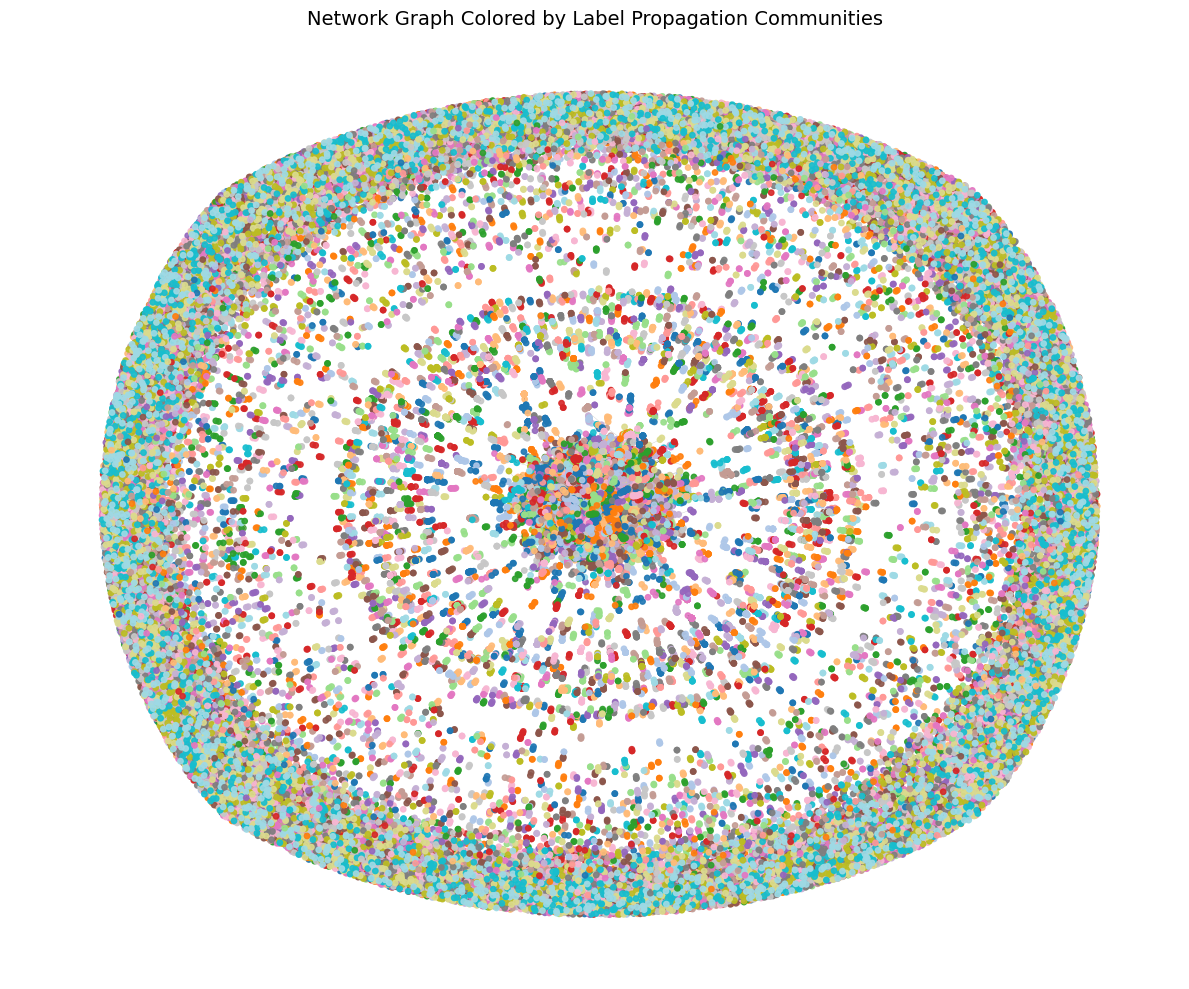

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load nodes and edges
nodes_df = pd.read_csv("nodes.csv")
edges_df = pd.read_csv("edges.csv")
community_df = pd.read_csv("communities.csv")

# Map community IDs to nodes
community_map = dict(zip(community_df['user_name'], community_df['community_id']))

# Assign colors to each community
unique_communities = sorted(community_df['community_id'].unique())
cmap = cm.get_cmap('tab20', len(unique_communities))
color_dict = {community: cmap(i) for i, community in enumerate(unique_communities)}

# Assign node colors
node_colors = [color_dict.get(community_map.get(node, -1), (0.5, 0.5, 0.5, 0.5)) for node in G.nodes]

# Layout and plot
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)  # Layout for consistent plotting

nx.draw_networkx_nodes(G, pos, node_size=15, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.3)

plt.title("Network Graph Colored by Label Propagation Communities", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
